# 03 — Director outputs: communities around the core (2026-10-02)

**Purpose.** The communities analysis read against the Y2Y-wide core: which communities sit close to the land the
framework identifies for conservation, and which of those have **no bear coexistence group recorded** in their census
division / county. Two maps in the Act 1 format (`director_plot._wide_map`: the Y2Y frame at left, zoom insets A / B at
right, key below) + one table. **Zero solves.** Reads the Y2Y-wide director package (balanced core, manifest v4) through
`director_plot.load()`, the coexistence layer through `director_core.coexistence_layer` (the 108 units + the region
lookup), and GeoNames `cities1000` (populated places ≥ 1,000 people; `input_data/basemap/geonames_cities1000.txt`, added 2026-10-01;
Natural Earth 1:10m as the fallback) as the community points.

**Method, as built (to be revisited tomorrow — written here so the maps are not read as more than they are):**
- *Core* = the balanced scenario's guarded f ≥ 0.70 (the package's Act 1 core), the WHOLE core: distances and buffers are measured from
  every core cell regardless of the clusters (Ethan 2026-10-02, final); the Act 1 picks only name the nearest region in the tables.
- *Community* = a GeoNames place inside Y2Y (+10 km) with population ≥ `MIN_POP` (1,000; the gazetteer goes down to 500 — the cut-off ladder is printed in §communities). *Distance* = Euclidean distance on the 1 km
  grid from the place's cell to the nearest cell of a numbered cluster (frequent specks outside the clusters are core land, not a cluster).
- *In the core* = the community's own 1 km cell is core land (f ≥ 0.70) — listed first, ahead of every buffer (Ethan 2026-10-02).
- *Buffers* (Ethan 2026-10-02, grizzly bear): **2 km** = third-order selection, zone of influence / avoidance (1.8 km rounded
  up; Thompson et al. 2025; Whittington et al. 2022); **10 km** = female second-order home range; **20 km** = male second-order
  home range (Graham & Stenhouse 2014). *Close* = within the 20 km buffer (`NEAR_KM`).
- *Has a coexistence program* = the community's census division / county records ≥ 1 group in the C&C layer — the layer
  carries no towns, so the division's count is attached to every community inside it (point size = that count). The four
  name-collision divisions (counts copied from a namesake, 01 §4) are treated as **none recorded**. NA stays NA. The
  divisions themselves are not drawn (Ethan 2026-10-02); they only attach counts to communities.
- Outputs → `director_package/` (y2y convention): `tables/`, `director_outputs/`, `summary.json`.
- Map 1 = the divisions by programs on record (the 01 surface) with the core outlined in yellow, no community points; map 2 = the buffers with the communities inside 20 km.


In [1]:
# ---- Setup ----------------------------------------------------------------------------------------------------
import sys, os, json, pathlib, importlib
import numpy as np, pandas as pd, geopandas as gpd, rasterio
from scipy import ndimage
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend import Legend
from matplotlib.legend_handler import HandlerTuple
from shapely.geometry import box as shp_box, Point
from shapely.ops import nearest_points
import matplotlib.patheffects as pe
from matplotlib.transforms import Bbox
import matplotlib.text as mtext

_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, "config.py not found above cwd -- run from inside the repo"
ROOT = _cands[0]; sys.path.insert(0, str(ROOT))
import config, director_core as dc, director_plot as dp
for _m in (config, dc, dp): importlib.reload(_m)

HERE = ROOT / "analyses" / "communities"
PKG = pathlib.Path(os.environ.get("COMMUNITIES_PKG", HERE / "director_package"))   # env override = headless smoke hook only
TAB, OUT = PKG / "tables", PKG / "director_outputs"
for _d in (TAB, OUT): _d.mkdir(parents=True, exist_ok=True)

BANDS_KM = (2, 10, 20)            # grizzly buffers: 2 km zone of influence / 10 km female / 20 km male home range (Ethan 2026-10-02)
NEAR_KM = BANDS_KM[-1]            # "close to the core" = inside the outermost buffer
MIN_POP = 1000                    # population cut-off for the community set (Ethan 2026-10-02: 62 inside the buffers at >= 500 was too many)
GEONAMES = next((q for q in (config.INPUT_DIR / "basemap" / "geonames_cities500.txt", config.INPUT_DIR / "basemap" / "geonames_cities1000.txt") if q.exists()),
                config.INPUT_DIR / "basemap" / "geonames_cities500.txt")   # primary gazetteer: GeoNames cities500 (pop >= 500, 323 inside Y2Y; Ethan 2026-10-02), else cities1000
PLACES = config.INPUT_DIR / "basemap" / "ne_10m_populated_places.shp"     # fallback: Natural Earth 1:10m (32 inside Y2Y)
UNITS_AUDIT = HERE / "audit" / "bear_coexistence_units.csv"    # 01's per-unit table (suspect flags); fallback below

print(f"package -> {PKG}"); print(f"core basis / version: see C.S after load; NEAR_KM = {NEAR_KM}")


package -> /Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/analyses/communities/director_package
core basis / version: see C.S after load; NEAR_KM = 20


In [2]:
# ---- The Y2Y-wide package (balanced core, v4) + the coexistence layer -----------------------------------------
# ---- the Act 1 format, exactly as 21_director_outputs sets it (Ethan 2026-10-02) ----
import matplotlib.pyplot as plt
plt.rcParams.update(dp.SPEC_RC)                 # the table spec's type (Candara) on every figure
dp.STYLE["titles"] = False                      # the slide carries the title
dp.STYLE["export_dpi"] = 300                    # full-screen slides
dp.STYLE["pa_borders"] = ("white", 0.3, 0.75)
INSET_CLUSTERS = (3, 4)                         # the ONE deviation from Act 1's fixed A/B windows (Stikine / Kootenays): insets on the two clusters
dp.STYLE["inset_windows"] = None; dp.STYLE["inset_clusters"] = INSET_CLUSTERS
dp.STYLE["inset_codes"] = {"A": dict(skip=["WA"]), "B": dict(skip=["WA"], force=["OR"])}   # OR pinned into inset B: Joseph + Enterprise are in Oregon (Ethan 2026-10-02)   # with communities around them; set inset_windows back to dp's default to match Act 1 exactly
C = dp.load()                                   # seconds: grid, basemap, package surfaces, clusters, picks
G = C.G
core_pu = (C.Fg >= dc.FREQ_THR) & G.disc                       # the core = frequent UNPROTECTED land (Act 1); locked PAs carry f = 1 but are not "core"
print("package:", C.S["version"], "| core basis:", C.S.get("core_basis"), "| core km2 (unprotected, f >= 0.70):", int(core_pu.sum()))

CX = dc.coexistence_layer(G)                    # gdf (108 units + region lookup) and 1 km zone ids 1..108
assert CX is not None, "region_lookup.csv missing -- run 02_region_names first"
units = CX.gdf.copy()
units["n_groups"] = pd.to_numeric(units["n_groups"], errors="coerce")
units["name"] = units["MappingUnit"].str.rsplit("_", n=1).str[0]           # the division / county name without the (unreliable) suffix
if UNITS_AUDIT.exists():
    au = pd.read_csv(UNITS_AUDIT, index_col="fid")
    suspect = set(au.index[au["name_collision"] & ~au["state_label_ok"]])
else:
    suspect = {52, 56, 103, 104}                # 01 §4: Madison ID, Teton ID, Lincoln WY, Park WY (counts copied from namesakes)
units["suspect"] = units.index.isin(suspect)
units["programs"] = np.where(units["suspect"], np.nan, units["n_groups"])         # the copied counts are NOT programs on record
units["status"] = np.where(units["programs"] >= 1, "recorded", "none")
print(units["status"].value_counts().to_dict(), "| groups as shipped:", int(units.n_groups.sum()),
      "| programs on record (suspect copies set aside):", int(units.programs.sum()), "| suspect divisions:", int(units.suspect.sum()))
zones = CX.zones
# per-cell programs on record in the division (0 = none recorded, incl. the suspect copies), NaN outside the units -- map 1's surface
unit_programs = units["programs"].fillna(0).to_numpy(dtype=np.float32)
count2d = np.where(zones > 0, unit_programs[np.clip(zones, 1, None) - 1], np.nan).astype(np.float32)

core2d = dc.to_grid(G, core_pu.astype(np.float32), fill=0.0) > 0            # all core land (drawn yellow on map 2)

# the Act 1 picks as polygons (regional complexes, numbered N -> S) = "the clusters"
picks = C.PICKS[C.PICKS.act == "Act 1"].copy()
act1 = C.CL["act1"]
pick_geoms = []
for _, r in picks.iterrows():
    cids = [int(c) for c in str(r.cids).split(";")]
    pick_geoms.append(act1[act1.cid.isin(cids)].union_all())
picks = gpd.GeoDataFrame(picks, geometry=pick_geoms, crs=act1.crs)
if "region" not in picks.columns:                                           # the package's picks carry region words once 19 has run 02_region_names' lookup
    picks["region"] = picks["name"].str.replace(r" \(.*\)$", "", regex=True)
picks["region"] = picks["region"].fillna(picks["name"])
print(picks[["number", "km2", "region"]].to_string(index=False))

# distance (km) from every cell to the nearest CORE cell -- the WHOLE core, every f >= 0.70 cell, regardless of the clusters
# (Ethan 2026-10-02, final: "forget the clusters, do the whole core"); the picks are kept only to name the nearest region
dist_km = ndimage.distance_transform_edt(~core2d) * (abs(G.transform.a) / 1000.0)


package: v4 | core basis: balanced | core km2 (unprotected, f >= 0.70): 51580
{'none': 82, 'recorded': 26} | groups as shipped: 53 | programs on record (suspect copies set aside): 47 | suspect divisions: 4
number     km2                            region
     1  2232.0                             Yukon
     2 11888.0                           Stikine
     3 17815.0    Kootenays / Columbia Mountains
     4  8638.0 Central Idaho / Salmon–Bitterroot


In [3]:
# ---- Communities: Natural Earth populated places inside Y2Y, scored against the core -------------------------------
if GEONAMES.exists():
    _gn_cols = ["geonameid", "name", "asciiname", "alternatenames", "lat", "lon", "fclass", "fcode", "country", "cc2", "admin1", "admin2",
                "admin3", "admin4", "population", "elevation", "dem", "tz", "mod"]
    _d = pd.read_csv(GEONAMES, sep="\t", header=None, names=_gn_cols, low_memory=False, keep_default_na=False, na_values=[""])
    _d = _d[_d.country.isin(["CA", "US"]) & _d.lon.between(-142, -107) & _d.lat.between(41, 68)]
    _CA = {"01": "Alberta", "02": "British Columbia", "11": "Yukon", "13": "Northwest Territories"}
    _US = {"ID": "Idaho", "MT": "Montana", "WA": "Washington", "WY": "Wyoming", "OR": "Oregon", "UT": "Utah", "NV": "Nevada"}
    _d = _d.assign(admin1_name=np.where(_d.country == "CA", _d.admin1.map(_CA), _d.admin1.map(_US)))
    pl = gpd.GeoDataFrame(_d[["name", "population", "fcode", "admin1_name"]].rename(columns={"name": "NAME", "population": "POP_MAX"}),
                          geometry=gpd.points_from_xy(_d.lon, _d.lat), crs=4326).to_crs(G.crs)
    PLACES_NOTE = "GeoNames cities500 (population ≥ 500)" if "500" in GEONAMES.name else "GeoNames cities1000 (population ≥ 1,000)"
else:
    pl = gpd.read_file(PLACES, columns=["NAME", "ADM0NAME", "ADM1NAME", "POP_MAX"]).rename(columns={"ADM1NAME": "admin1_name"})
    pl = pl[pl.ADM0NAME.isin(["Canada", "United States of America"])].to_crs(G.crs)
    PLACES_NOTE = "Natural Earth 1:10m populated places"
y2y = gpd.read_file(config.CORRIDOR_REF).to_crs(G.crs).union_all().buffer(10_000)
pl = pl[pl.within(y2y)].reset_index(drop=True)
_n_all = len(pl)                                 # the cut-off is applied AFTER scoring (below), so the ladder sees every place
px, py = dc.xy_to_px(G, pl.geometry.x.values, pl.geometry.y.values)
col, row = np.floor(px).astype(int), np.floor(py).astype(int)
inb = (row >= 0) & (row < G.shape[0]) & (col >= 0) & (col < G.shape[1])
pl = pl[inb].reset_index(drop=True); col, row, px, py = col[inb], row[inb], px[inb], py[inb]
pl["px"], pl["py"] = px, py
pl["dist_core_km"] = dist_km[row, col]
pl["in_core"] = core2d[row, col]                   # the community's own cell is core land (any core cell; Ethan 2026-10-02)
pl["zone"] = zones[row, col]
has_unit = pl["zone"] > 0
pl["unit"] = np.where(has_unit, units["name"].reindex(pl["zone"] - 1).values, "outside the C&C layer")   # the layer is clipped to Y2Y; a few places sit in the 10 km margin
pl["unit_admin1"] = np.where(has_unit, units["admin1"].reindex(pl["zone"] - 1).values, "")
pl["unit_region"] = np.where(has_unit, units["region"].reindex(pl["zone"] - 1).values, "")
pl["unit_status"] = np.where(has_unit, units["status"].reindex(pl["zone"] - 1).values, "none")
pl["unit_n_groups"] = np.where(has_unit, units["programs"].reindex(pl["zone"] - 1).values, np.nan)   # programs on record in the community's division
pl["unit_suspect"] = np.where(has_unit, units["suspect"].reindex(pl["zone"] - 1).values, False)
# nearest Act 1 cluster (pick) by polygon distance
D = np.column_stack([pl.geometry.distance(g).values for g in picks.geometry]) / 1000.0
pl["nearest_cluster"] = picks["number"].values[D.argmin(axis=1)]
pl["nearest_cluster_km"] = D.min(axis=1)
pl["nearest_cluster_region"] = picks["region"].values[D.argmin(axis=1)]
pl = pl.rename(columns={"NAME": "community", "POP_MAX": "population"}).sort_values("dist_core_km")
pl_all = pl.copy()                                                     # every gazetteer place (the cut-off ladder)
pl = pl[pl["population"].fillna(0) >= MIN_POP].reset_index(drop=True)
print(f"gazetteer places inside Y2Y (+10 km): {_n_all}; kept at population >= {MIN_POP:,}: {len(pl)}")
pl["admin1"] = np.where(pl["unit_admin1"].astype(str).str.len() > 0, pl["unit_admin1"], pl["admin1_name"])   # province / state: the containing division, else the gazetteer

pl["buffer_km"] = pd.cut(pl["dist_core_km"], bins=[-0.01] + list(BANDS_KM), labels=[f"≤ {b} km" for b in BANDS_KM]).astype(object)
pl.loc[pl.in_core, "buffer_km"] = "in the core"                    # the core itself outranks every buffer
near = pl[(pl.dist_core_km <= NEAR_KM) | pl.in_core].copy()
print(f"communities IN THE CORE: {int(pl.in_core.sum())} (no program: {int((pl.in_core & (pl.unit_status == 'none')).sum())}): "
      + ", ".join(pl.loc[pl.in_core, "community"]))
gap = near[near.unit_status == "none"].copy()
print(f"communities inside Y2Y (+10 km): {len(pl)}   within {NEAR_KM} km of the core: {len(near)}   "
      f"of which with NO program recorded: {len(gap)}   with a program: {(near.unit_status == 'recorded').sum()}   "
      f"(suspect divisions counted as none: {int(near.unit_suspect.sum())})")
for _cut in (500, 1000, 2000, 5000):                                   # the cut-off ladder, for choosing MIN_POP
    _m = ((pl_all.dist_core_km <= NEAR_KM) | pl_all.in_core) & (pl_all.population.fillna(0) >= _cut)
    print(f"  population >= {_cut:>5,}: {int(_m.sum()):3d} communities inside {NEAR_KM} km, {int((_m & (pl_all.unit_status == 'none')).sum()):3d} with no program")
print("by buffer:", near.groupby("buffer_km", observed=True).agg(communities=("community", "size"), no_program=("unit_status", lambda s: (s == "none").sum())).to_dict("index"))
by_cluster = (near.assign(no_program=near.unit_status.eq("none"), with_program=near.unit_status.eq("recorded"))
                  .groupby("nearest_cluster").agg(communities=("community", "size"), no_program=("no_program", "sum"), with_program=("with_program", "sum"))
                  .reindex(picks["number"].values).fillna(0).astype(int))
by_cluster.insert(0, "region", picks.set_index("number")["region"].reindex(by_cluster.index).values)
print(by_cluster.to_string())

cols = ["community", "admin1", "population", "in_core", "dist_core_km", "buffer_km", "nearest_cluster", "nearest_cluster_region", "nearest_cluster_km",
        "unit", "unit_admin1", "unit_status", "unit_n_groups", "unit_suspect"]
pl[cols].round({"dist_core_km": 1, "nearest_cluster_km": 1}).to_csv(TAB / "communities_all.csv", index=False)
near[cols].round({"dist_core_km": 1, "nearest_cluster_km": 1}).to_csv(TAB / "communities_near_core.csv", index=False)
by_cluster.to_csv(TAB / "communities_by_cluster.csv")
print("\nwithin", NEAR_KM, "km, no program recorded (nearest first):")
print(gap[["community", "admin1", "population", "dist_core_km", "buffer_km", "nearest_cluster", "unit"]].round(1).to_string(index=False))


gazetteer places inside Y2Y (+10 km): 323; kept at population >= 1,000: 218
communities IN THE CORE: 2 (no program: 2): Joseph, Enterprise
communities inside Y2Y (+10 km): 218   within 20 km of the core: 151   of which with NO program recorded: 77   with a program: 74   (suspect divisions counted as none: 6)
  population >=   500: 232 communities inside 20 km, 124 with no program
  population >= 1,000: 151 communities inside 20 km,  77 with no program
  population >= 2,000:  87 communities inside 20 km,  44 with no program
  population >= 5,000:  40 communities inside 20 km,  18 with no program
by buffer: {'in the core': {'communities': 2, 'no_program': 2}, '≤ 10 km': {'communities': 84, 'no_program': 44}, '≤ 20 km': {'communities': 65, 'no_program': 31}}
                                            region  communities  no_program  with_program
nearest_cluster                                                                          
1                                            Yukon    

## Map 1 — bear coexistence programs around the core

Act 1 format. Surface = each census division / county by the programs on record (none / 1 / 2 / 3 / 4, as in 01); the core
(f ≥ 0.70, "Core 30×30 allocation") as a translucent yellow fill so the divisions show underneath; no park names; no community points — the basemap's reference towns only;
divisions with ≥ 3 programs named in the insets (Ethan 2026-10-02).
Every community inside Y2Y as a point: black, sized by the number of programs on record, or a white circle with a red
outline where none is recorded. No division boundaries.

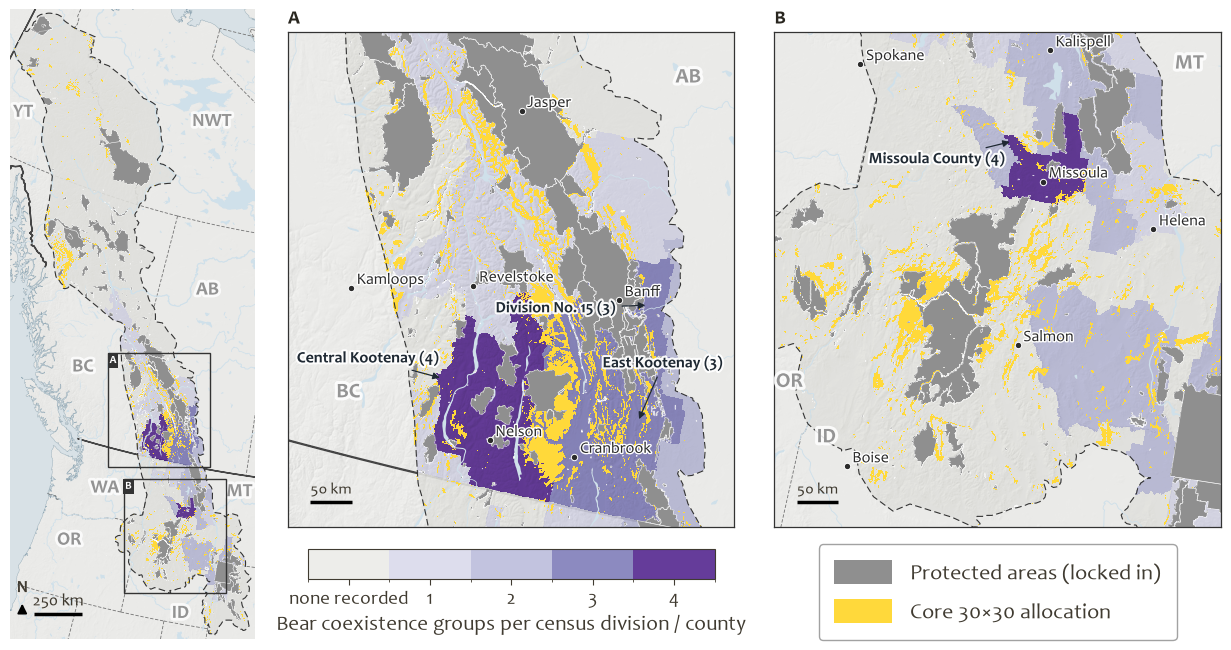

In [4]:
INK, HOLLOW_EDGE = "#1F2933", "#B03A2E"
is_frame = lambda win: (win[1] - win[0]) > 0.8 * G.shape[1]
SIZE_FRAME, SIZE_INSET = (3, 11), (10, 36)        # marker area = a + b * programs (frame / inset)

def _in_win(df, win):
    px0, px1, pyt, pyb = win
    return df[(df.px >= px0) & (df.px <= px1) & (df.py >= pyt) & (df.py <= pyb)]

def _marker_sizes(d, kind, frame):
    a, b = SIZE_FRAME if frame else SIZE_INSET
    return (a + b * d.unit_n_groups.fillna(1)) if kind == "recorded" else pd.Series((a + b) * 1.15, index=d.index)

def _draw_places(ax, win, df, kind):
    d = _in_win(df, win); frame = is_frame(win); s_ = _marker_sizes(d, kind, frame)
    core_fill = d.in_core.fillna(False).astype(bool)            # a community ON core land: the Act 1 yellow inside its outline (Ethan 2026-10-02)
    if kind == "recorded":
        ax.scatter(d.px, d.py, s=s_, c=np.where(core_fill, CORE_YELLOW, INK), edgecolors=np.where(core_fill, INK, "white"), linewidths=np.where(core_fill, 1.1, 0.5), zorder=9)
    else:
        ax.scatter(d.px, d.py, s=s_, facecolors=np.where(core_fill, CORE_YELLOW, "white"), edgecolors=HOLLOW_EDGE, linewidths=1.1, zorder=9)
    return d.assign(_ms=s_)

LABEL_MIN_POP_RECORDED = 5000                   # communities WITH a program are named only at/above this population (regional centres); every
                                                # no-program community is eligible -- they are the map's subject (Ethan 2026-10-02: "can't have them all")
LABEL_CANDIDATES = [(5, 3, "left", "bottom"), (5, -3, "left", "top"), (-5, 3, "right", "bottom"), (-5, -3, "right", "top"),
                    (0, 9, "center", "bottom"), (0, -9, "center", "top"), (9, 9, "left", "bottom"), (-9, -9, "right", "top"),
                    (14, 0, "left", "center"), (-14, 0, "right", "center"), (0, 16, "center", "bottom"), (0, -16, "center", "top")]
LABEL_FS = dp.STYLE["inset_fs"]                 # community names at the SAME size as the basemap's town names in the Act 1 insets (11.5 pt; Ethan 2026-10-02)
LABEL_PAD_PX = 4                                # breathing room between a label and anything it is tested against (display pixels)
LABEL_LEADER_POP = 20000                        # a centre this large that finds no clear spot beside its dot is named further out with a leader line
LEADER_CANDIDATES = [(dx * r, dy * r, "left" if dx > 0 else ("right" if dx < 0 else "center"), "bottom" if dy > 0 else ("top" if dy < 0 else "center"))
                     for r in (26, 38) for dx, dy in ((1, 1), (-1, 1), (1, -1), (-1, -1), (1, 0), (-1, 0), (0, 1), (0, -1))]
def _seg_hits(p0, p1, bb):
    # does the segment p0 -> p1 cross the box? (Liang-Barsky clip in display pixels)
    (x0, y0), (x1, y1) = p0, p1; dx, dy = x1 - x0, y1 - y0; t0, t1 = 0.0, 1.0
    for pq in ((-dx, x0 - bb.x0), (dx, bb.x1 - x0), (-dy, y0 - bb.y0), (dy, bb.y1 - y0)):
        pp, q = pq
        if pp == 0:
            if q < 0: return False
            continue
        t = q / pp
        if pp < 0: t0 = max(t0, t)
        else:      t1 = min(t1, t)
        if t0 > t1: return False
    return True

def _label_points(ax, d, fs):
    # a greedy placer: eligible communities in priority order (no-program first, then by population); each label tries the candidate
    # offsets and keeps the first that overlaps NOTHING -- no text already on the axes (jurisdiction codes, the inset letter, labels placed
    # before it), no marker, no leader line, nothing past the inset's edge; large centres boxed in by their neighbours get a leader line
    # to a clear spot further out, and the line itself may cross no text; if every offset collides the community stays an UNLABELLED dot
    # (Ethan 2026-10-02: clean, not exhaustive; "no text overlaps anywhere")
    r = ax.figure.canvas.get_renderer(); axbb = ax.get_window_extent(r); k = ax.figure.dpi / 72
    placed = list(getattr(ax, "_community_label_boxes", []))
    placed += [t_.get_window_extent(r) for t_ in ax.texts if t_.get_visible() and t_.get_text()]       # every text already on the inset
    placed.append(Bbox.from_extents(axbb.x0, axbb.y0, axbb.x0 + 0.22 * axbb.width, axbb.y0 + 0.11 * axbb.height))   # the SW corner: the 50 km scale bar
    leaders = list(getattr(ax, "_community_leaders", []))
    pts = ax.transData.transform(np.c_[d.px.values, d.py.values])
    rad = np.sqrt(d._ms.values) / 2 * k + 1.5                                    # marker radius in display pixels (+ a hair of edge)
    markers = [Bbox.from_extents(x - q, y - q, x + q, y + q) for (x, y), q in zip(pts, rad)]
    kw = dict(textcoords="offset points", fontsize=fs, color=INK, zorder=10, path_effects=[pe.withStroke(linewidth=2.2, foreground="white", alpha=0.9)])
    order = d.assign(_gap=(d.unit_status == "none"), _pop=d.population.fillna(0)).sort_values(["_gap", "_pop"], ascending=[False, False])
    n_lab = 0
    for _, row in order.iterrows():
        if not row._gap and row._pop < LABEL_MIN_POP_RECORDED:
            continue
        i = d.index.get_loc(row.name); own = markers[i]; p0 = tuple(pts[i])
        cands = [(dx, dy, ha, va, False) for dx, dy, ha, va in LABEL_CANDIDATES]
        if row._pop >= LABEL_LEADER_POP:
            cands += [(dx, dy, ha, va, True) for dx, dy, ha, va in LEADER_CANDIDATES]
        for dx, dy, ha, va, lead in cands:
            arrow = dict(arrowstyle="-", lw=0.7, color=INK, shrinkA=0, shrinkB=np.sqrt(row._ms) / 2 + 1) if lead else None
            t = ax.annotate(row.community, (row.px, row.py), xytext=(dx, dy), ha=ha, va=va, arrowprops=arrow, **kw)
            t.update_positions(r); bb0 = mtext.Text.get_window_extent(t, r)   # the TEXT's box alone (an annotation's extent would include its leader)
            bb = Bbox.from_extents(bb0.x0 - LABEL_PAD_PX, bb0.y0 - LABEL_PAD_PX, bb0.x1 + LABEL_PAD_PX, bb0.y1 + LABEL_PAD_PX)
            clear = axbb.contains(bb0.x0, bb0.y0) and axbb.contains(bb0.x1, bb0.y1)
            clear = clear and not any(bb.overlaps(b) for b in placed) and not any(bb.overlaps(m) for m in markers if m is not own)
            clear = clear and not any(_seg_hits(a, b, bb) for a, b in leaders)
            if clear and lead:
                p1 = (p0[0] + dx * k, p0[1] + dy * k)                                   # the leader runs from the dot to the text's anchor
                clear = not any(_seg_hits(p0, p1, b) for b in placed)
            if clear:
                placed.append(bb); n_lab += 1
                if lead: leaders.append((p0, p1))
                break
            t.remove()
    ax._community_label_boxes = placed; ax._community_leaders = leaders
    return n_lab, len(order)

def draw_clusters(ax):                          # Ethan 2026-10-02: no cluster outlines or numbers -- the core (yellow) carries itself
    return None

def size_handles(scope):
    # two legend entries so the Act 1 box stays level with the ramp: programs on record (point size = count), none recorded
    a, b = SIZE_FRAME
    return [Line2D([], [], marker="o", ls="", ms=np.sqrt(a + b * 2) * 1.6, mfc=INK, mec="white", label=f"{scope}N programs"),
            Line2D([], [], marker="o", ls="", ms=7, mfc="white", mec=HOLLOW_EDGE, mew=1.3, label=f"{scope}none recorded")]

CORE_YELLOW = "#ffd93b"
CORE_ALPHA = 1.0                                # opaque Act 1 yellow (a translucent fill went olive over the dark-blue divisions; the core is a small share of each division)
core_rgba = np.zeros(G.shape + (4,), dtype=np.float32); core_rgba[core2d] = (1.0, 0.851, 0.231, CORE_ALPHA)
def draw_core(ax):
    ax.imshow(core_rgba, interpolation="nearest", zorder=1.5)
COUNT_STEPS = ["#ECECE8", "#DADAEB", "#BCBDDC", "#807DBA", "#54278F"]          # none, 1, 2, 3, 4 (one hue, light -> dark; PURPLE so the division counts never read as map 2's blue distance rings -- Ethan 2026-10-03)
surface1 = dict(img=count2d, cmap=ListedColormap(COUNT_STEPS), norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 5), extend="neither",
                ticks=[0, 1, 2, 3, 4], ticklabels=["none recorded", "1", "2", "3", "4"], label="Bear coexistence groups per census division / county",
                end_words=None, alpha=0.9)
CALLOUT_MIN = 3                                 # divisions with >= this many programs are named in the insets (as in 01)
CALLOUT_MIN_SHARE = 0.03                         # a division showing less than this share of its area in a window gets no callout there
CALLOUT_FS = 11.5                                # the same size as the town names
CALLOUT_MIN_ARROW = 38                           # points: the name stands at least this far from the division's edge, so the arrow reads as one
CALLOUT_RING = [(r * np.cos(a), r * np.sin(a)) for r in (70, 95, 120, 150, 185) for a in np.deg2rad((0, 180, 45, 135, -45, -135, 90, -90, 20, 160, -20, -160, 70, 110, -70, -110))]
CALLOUT_AT = {"Central Kootenay": (0.18, 0.34), "East Kootenay": (0.84, 0.33)}   # name -> (x, y) as a fraction of the INSET frame: a hand placement that overrides
                                                 # the search (CK: out in the open BC land to the west; EK: over Banff NP, pointing down into the division)
CALLOUT_TIP = {"East Kootenay": (0.785, 0.215)}  # name -> (x, y) fraction of the inset frame where the ARROW lands (must lie on the division's visible part;
                                                 # else the nearest-point rule applies) -- EK's a little further south (Ethan 2026-10-03)
_PA_UNION = (C.PA_GDF if getattr(C, "PA_GDF", None) is not None else gpd.read_file(config.PA_VECTOR).to_crs(G.crs)).geometry.union_all()
def _window_box(win):
    px0, px1, pyt, pyb = win
    (x0, y0), (x1, y1) = G.transform * (px0, pyb), G.transform * (px1, pyt)
    return shp_box(min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1))
def label_divisions(ax, win):
    # callouts with ARROWS (Ethan 2026-10-03): the name sits in clear space -- off the division, inside the inset, overlapping no text
    # already drawn (towns, codes), its arrow crossing none -- and points at the nearest interior point of the division's part
    # inside this window; the search walks a ring of offsets around the visible centre (CALLOUT_RING), CALLOUT_AT pins one by hand
    r = ax.figure.canvas.get_renderer(); axbb = ax.get_window_extent(r); k = ax.figure.dpi / 72; inv = ax.transData.inverted()
    taken = [t_.get_window_extent(r) for t_ in ax.texts if t_.get_visible() and t_.get_text()]
    taken.append(Bbox.from_extents(axbb.x0, axbb.y0, axbb.x0 + 0.22 * axbb.width, axbb.y0 + 0.11 * axbb.height))   # the scale bar's corner
    wb = _window_box(win)
    kw = dict(ha="center", va="center", fontsize=CALLOUT_FS, fontweight=600, color=INK, zorder=11, path_effects=[pe.withStroke(linewidth=3, foreground="white", alpha=0.95)])
    callout_units = units[units.programs >= CALLOUT_MIN]
    for _, row in callout_units.sort_values("programs", ascending=False).iterrows():
        g = row.geometry.intersection(wb)
        if g.is_empty or g.area < CALLOUT_MIN_SHARE * row.geometry.area:
            continue
        # the arrow points at the part of the division the reader can SEE as the division: inside the window, with the protected areas
        # cut out (Division No. 15 is Alberta's Rocky Mountain parks division, East Kootenay holds Kootenay + Yoho -- the grey park fill
        # hides the division colour there; Ethan 2026-10-03), 4 km inside its edge
        gv = g.difference(_PA_UNION); gv = gv if not gv.is_empty else g
        gi = gv.buffer(-4000); gi = gi if not gi.is_empty else gv
        c = gi.representative_point(); c_disp = ax.transData.transform(dc.xy_to_px(G, c.x, c.y))
        text = f"{row['name']} ({int(row.programs)})"
        by_hand = row["name"] in CALLOUT_AT
        cands = [CALLOUT_AT[row["name"]]] if by_hand else CALLOUT_RING
        others = callout_units[callout_units["name"] != row["name"]].geometry
        for dx, dy in cands:
            t_disp = (axbb.x0 + dx * axbb.width, axbb.y0 + dy * axbb.height) if by_hand else (c_disp[0] + dx * k, c_disp[1] + dy * k)
            tpx = inv.transform(t_disp); tx, ty = G.transform * (tpx[0], tpx[1]); tp = Point(tx, ty)
            if not by_hand and (g.contains(tp) or others.contains(tp).any()):   # the name sits OFF this division and off every other callout division
                continue
            q = c if g.contains(tp) else nearest_points(gi, tp)[0]                    # a hand placement inside the division points at its centre
            if row["name"] in CALLOUT_TIP:
                fx, fy = CALLOUT_TIP[row["name"]]; hpx = inv.transform((axbb.x0 + fx * axbb.width, axbb.y0 + fy * axbb.height))
                hp = Point(*(G.transform * (hpx[0], hpx[1])))
                q = hp if gv.contains(hp) else q
            qpx = dc.xy_to_px(G, q.x, q.y)
            q_disp = ax.transData.transform(qpx)
            if not by_hand and np.hypot(q_disp[0] - t_disp[0], q_disp[1] - t_disp[1]) < CALLOUT_MIN_ARROW * k:
                continue
            t = ax.annotate(text, xy=qpx, xytext=tpx, textcoords="data", arrowprops=dict(arrowstyle="-|>", lw=0.9, color=INK, shrinkA=2, shrinkB=1, mutation_scale=10), **kw)
            t.update_positions(r); bb0 = mtext.Text.get_window_extent(t, r)
            bb = Bbox.from_extents(bb0.x0 - LABEL_PAD_PX, bb0.y0 - LABEL_PAD_PX, bb0.x1 + LABEL_PAD_PX, bb0.y1 + LABEL_PAD_PX)
            clear = axbb.contains(bb0.x0, bb0.y0) and axbb.contains(bb0.x1, bb0.y1) and not any(bb.overlaps(b) for b in taken)
            clear = clear and not any(_seg_hits(tuple(q_disp), tuple(t_disp), b) for b in taken)
            if clear:
                taken.append(bb); break
            t.remove()
        else:
            print(f"  callout NOT placed: {text}")
def post1(ax, win):                             # no community points on map 1 (Ethan 2026-10-02): divisions + core outline + the basemap's reference towns
    if not is_frame(win):
        label_divisions(ax, win)
handles1 = C.BASE_HANDLES[:1] + [Patch(facecolor=CORE_YELLOW, alpha=CORE_ALPHA, edgecolor="none", label="Core 30×30 allocation")]
n_rec_comm = int((pl.unit_status == "recorded").sum())
title1 = (f"Bear coexistence programs by census division / county, with the core outlined\n"
          f"{int((units.status == 'recorded').sum())} of 108 divisions record a program ({int(units.programs.sum())} programs, July 2026)")
_pa_names = dp.STYLE["inset_pa_names"]; dp.STYLE["inset_pa_names"] = 0          # no park names in the insets (Ethan 2026-10-02)
try:
    dp._wide_map(C, OUT / "01_coexistence_programs_around_core.png", title1, draw=draw_core, handles=handles1, surface=surface1, post_draw=post1)
finally:
    dp.STYLE["inset_pa_names"] = _pa_names


## Map 2 — communities within the grizzly buffers with no coexistence program recorded

Same format. Surface = the whole core (every f ≥ 0.70 cell, Act 1 yellow) and the distance from it in the three grizzly buffers (
≤ 2 km zone of influence; ≤ 10 km female home range; ≤ 20 km male home range). Points = the communities inside the 20 km
buffer: black sized by programs on record, white circle with red outline where none is recorded (named in the insets).

  inset: 12 no-program + 34 recorded communities drawn; 16 of 46 eligible names placed
  inset: 44 no-program + 25 recorded communities drawn; 28 of 69 eligible names placed


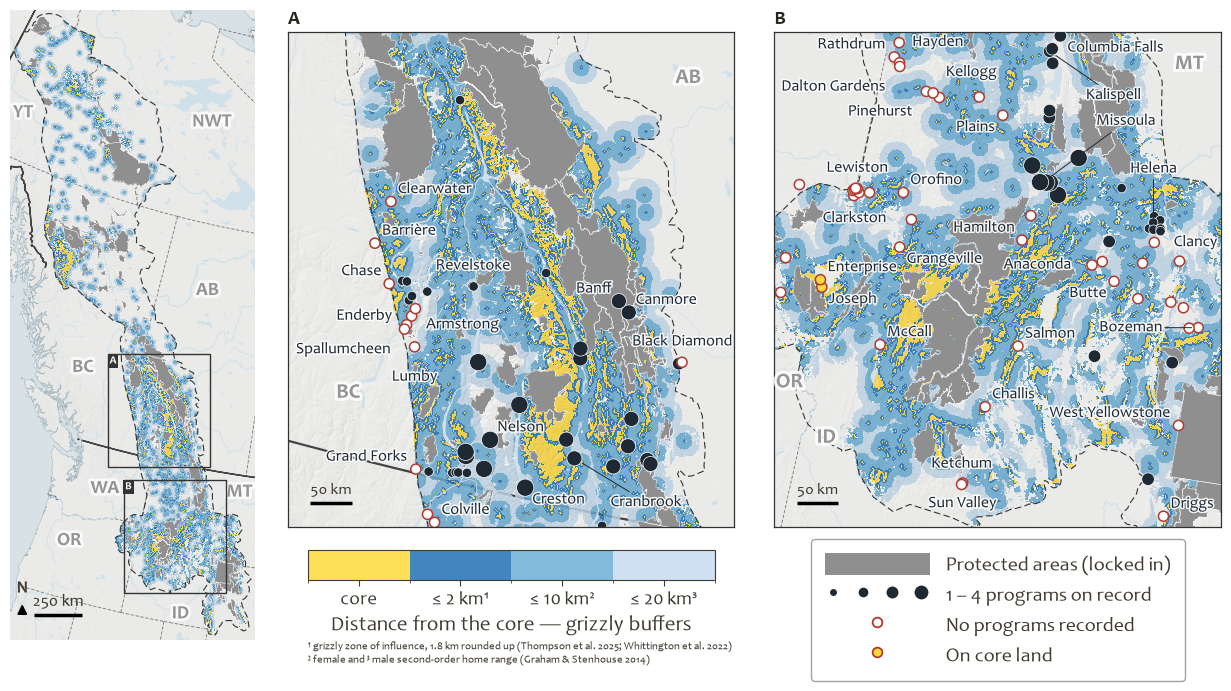

legend font used: 14.5


In [5]:
band2d = np.full(G.shape, np.nan, dtype=np.float32)
band2d[core2d] = 0                            # the whole core (every f >= 0.70 cell) in the Act 1 yellow
for i, (lo, hi) in enumerate(zip((0,) + BANDS_KM[:-1], BANDS_KM), start=1):
    band2d[G.pu & ~core2d & (dist_km > lo) & (dist_km <= hi)] = i
surface2 = dict(img=band2d, cmap=ListedColormap(["#ffd93b", "#2171B5", "#6BAED6", "#C6DBEF"]), norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4),
                extend="neither", ticks=[0, 1, 2, 3], ticklabels=["core", "≤ 2 km¹", "≤ 10 km²", "≤ 20 km³"],
                label="Distance from the core — grizzly buffers", end_words=None, alpha=0.85)
BUFFER_FOOTNOTE = ("¹ grizzly zone of influence, 1.8 km rounded up (Thompson et al. 2025; Whittington et al. 2022)\n"
                   "² female and ³ male second-order home range (Graham & Stenhouse 2014)")
def post2(ax, win):                             # communities in the INSETS only, every one named; the basemap's towns are OFF on this map (Ethan 2026-10-02)
    if not is_frame(win):
        d_rec = _draw_places(ax, win, near[near.unit_status == "recorded"], "recorded")
        d_gap = _draw_places(ax, win, gap, "none")
        n_lab, n_elig = _label_points(ax, pd.concat([d_gap, d_rec]), LABEL_FS)
        print(f"  inset: {len(d_gap)} no-program + {len(d_rec)} recorded communities drawn; {n_lab} of {n_elig} eligible names placed")
    if is_frame(win):                               # the citations, once, along the page bottom (the export box runs to the page bottom)
        ax.figure.text(0.285, 0.004, BUFFER_FOOTNOTE, fontsize=dp.STYLE["cbar_fs"] - 7, color=dp.TABLE["cap"], ha="left", va="bottom", linespacing=1.2)
class Ladder(tuple):                            # a legend entry holding several markers side by side (the size ladder on ONE line, Ethan 2026-10-02)
    def __new__(cls, items, label):
        self = super().__new__(cls, items); self._label = label; return self
    def get_label(self):
        return self._label
Legend.update_default_handler_map({Ladder: HandlerTuple(ndivide=None, pad=0.6)})
def ladder_handles():                           # the size ladder 1 -> 4 programs as one entry, then the red "none recorded" marker
    a, b = SIZE_FRAME
    ladder = Ladder((Line2D([], [], marker="o", ls="", ms=np.sqrt(a + b * n) * 1.6, mfc=INK, mec="white") for n in (1, 2, 3, 4)), "1 – 4 programs on record")
    return [ladder, Line2D([], [], marker="o", ls="", ms=7, mfc="white", mec=HOLLOW_EDGE, mew=1.3, label="No programs recorded"),
            Line2D([], [], marker="o", ls="", ms=7, mfc=CORE_YELLOW, mec=HOLLOW_EDGE, mew=1.3, label="On core land")]
handles2 = C.BASE_HANDLES[:1] + ladder_handles()
title2 = (f"Communities — within {NEAR_KM} km of a core cluster with no bear coexistence program recorded\n"
          f"{len(gap)} of {len(near)} communities inside the {NEAR_KM} km buffer around the core (male grizzly home range) have no program on record")
_saved = {k: dp.STYLE.get(k) for k in ("inset_pa_names", "inset_town_skip", "wide_main_towns", "wide_legend_between", "wide_legend_fit", "wide_legend_floor", "wide_legend_fs_min", "wide_legend_handlelength", "wide_legend_labelspacing", "wide_legend_page_floor")}
_all_towns = tuple(C.BM.towns) if getattr(C.BM, "towns", None) else ()
dp.STYLE.update(inset_pa_names=0,                                  # no park names in the insets (Ethan 2026-10-02, too cluttered)
                inset_town_skip={"A": _all_towns, "B": _all_towns}, wide_main_towns=(),   # no basemap towns: only communities inside the buffers appear (Ethan 2026-10-02)
                wide_legend_between=True, wide_legend_fit=True,    # four entries as large as the strip under inset B allows (its bottom edge to the page bottom;
                wide_legend_floor="page", wide_legend_page_floor=-0.03, wide_legend_fs_min=13,   # the floor dips below the page because _fit_page re-centres the
                                                                   # whole block before export; Ethan 2026-10-03: 9.5 pt in map 1's gap was far too small)
                wide_legend_handlelength=5.2,                       # room for the four-marker ladder in one handle box
                wide_legend_labelspacing=0.35)                      # entries a little closer together vertically (Ethan 2026-10-03)
try:
    dp._wide_map(C, OUT / "02_communities_in_grizzly_buffers_no_program.png", title2, draw=draw_clusters, handles=handles2, surface=surface2, post_draw=post2)
    print("legend font used:", dp.STYLE.get("_wide_legend_fs_used"))
finally:
    dp.STYLE.update(_saved)


## Table — the communities on map 2, by cluster

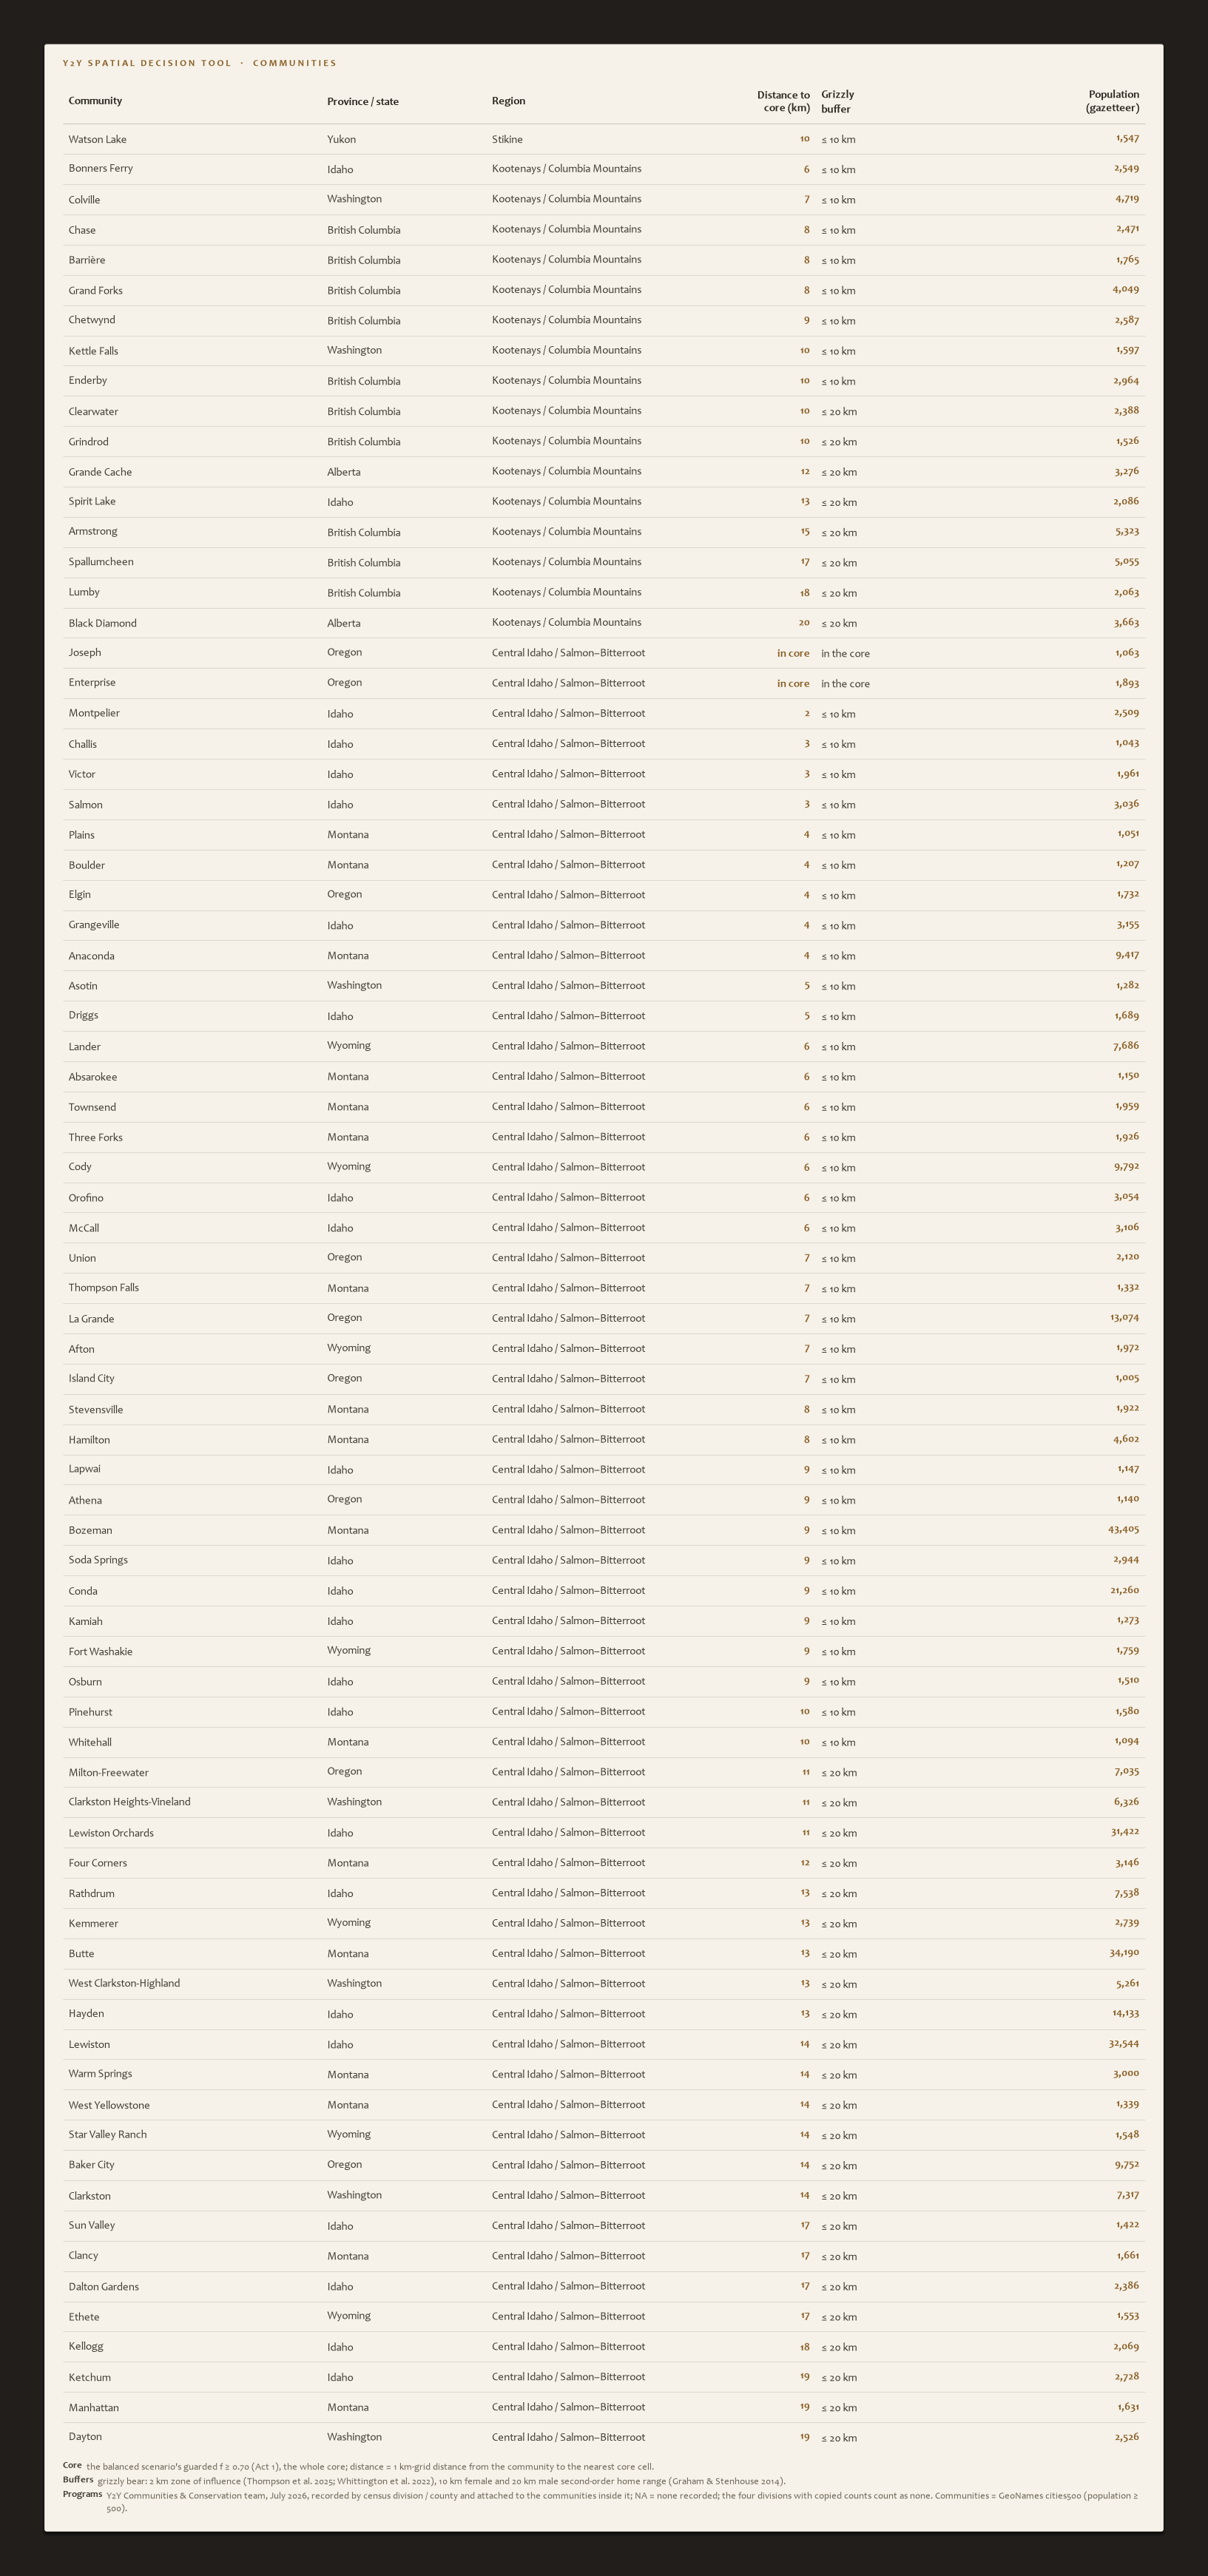

{
 "built": "2026-10-02",
 "package_version": "v4",
 "core_basis": "balanced",
 "near_km": 20,
 "buffers_km": [
  2,
  10,
  20
 ],
 "buffer_basis": "grizzly: 2 km zone of influence (Thompson et al. 2025; Whittington et al. 2022); 10 km female / 20 km male 2nd-order home range (Graham & Stenhouse 2014)",
 "communities_in_y2y": 218,
 "communities_with_program": 85,
 "within_near_km": 151,
 "no_program_within_near_km": 77,
 "in_core": 2,
 "in_core_no_program": 2,
 "min_pop": 1000,
 "with_program_within_near_km": 74,
 "suspect_divisions_counted_as_none": 4,
 "by_buffer": {
  "in the core": {
   "communities": 2,
   "no_program": 2
  },
  "\u2264 10 km": {
   "communities": 84,
   "no_program": 44
  },
  "\u2264 20 km": {
   "communities": 65,
   "no_program": 31
  }
 },
 "units_recorded": 26,
 "units_none": 82,
 "groups_as_shipped": 53,
 "programs_on_record": 47,
 "places_source": "GeoNames cities500 (population \u2265 500)"
}

outputs:
   director_outputs/.DS_Store
   director_outputs/01

[None, None, None, None, None, None, None]

In [6]:
t = gap.assign(_d=np.where(gap.in_core, -1.0, gap.dist_core_km)).sort_values(["nearest_cluster", "_d"], key=lambda s: s.astype(int) if s.name == "nearest_cluster" else s)
stub = [f"{r.community}" for _, r in t.iterrows()]
cols_t = ["Province / state", "Region", "Distance to\ncore (km)", "Grizzly\nbuffer", "Population\n(gazetteer)"]
cells = [[r.admin1, f"{r.nearest_cluster_region}", ("in core" if r.in_core else f"{r.dist_core_km:.0f}"), f"{r.buffer_km}", f"{int(r.population):,}" if pd.notna(r.population) else "—"]
         for _, r in t.iterrows()]
numeric = [[False, False, True, False, True] for _ in cells]
dp.spec_table_png(OUT / "03_communities_in_grizzly_buffers_no_program_table.png", stub, cols_t, cells, numeric=numeric, stub_head="Community",
                  label="Y2Y SPATIAL DECISION TOOL  ·  COMMUNITIES",
                  title=f"Communities within {NEAR_KM} km of the core with no bear coexistence program recorded" if dp.STYLE["titles"] else None,
                  notes=(("Core", "the balanced scenario's guarded f ≥ 0.70 (Act 1), the whole core; distance = 1 km-grid distance from the community to the nearest core cell."),
                         ("Buffers", "grizzly bear: 2 km zone of influence (Thompson et al. 2025; Whittington et al. 2022), 10 km female and 20 km male second-order home range (Graham & Stenhouse 2014)."),
                         ("Programs", "Y2Y Communities & Conservation team, July 2026, recorded by census division / county and attached to the communities inside it; NA = none recorded; the four divisions with copied counts count as none. Communities = " + PLACES_NOTE + ".")))
summary = dict(built="2026-10-02", package_version=C.S["version"], core_basis=C.S.get("core_basis"), near_km=NEAR_KM, buffers_km=list(BANDS_KM),
               buffer_basis="grizzly: 2 km zone of influence (Thompson et al. 2025; Whittington et al. 2022); 10 km female / 20 km male 2nd-order home range (Graham & Stenhouse 2014)",
               communities_in_y2y=int(len(pl)), communities_with_program=n_rec_comm, within_near_km=int(len(near)), no_program_within_near_km=int(len(gap)),
               in_core=int(pl.in_core.sum()), in_core_no_program=int((pl.in_core & (pl.unit_status == "none")).sum()), min_pop=MIN_POP,
               with_program_within_near_km=int((near.unit_status == "recorded").sum()), suspect_divisions_counted_as_none=int(units.suspect.sum()),
               by_buffer={str(k): v for k, v in near.groupby("buffer_km", observed=True).agg(communities=("community", "size"), no_program=("unit_status", lambda s: int((s == "none").sum()))).to_dict("index").items()},
               units_recorded=int((units.status == "recorded").sum()), units_none=int((units.status == "none").sum()),
               groups_as_shipped=int(units.n_groups.sum()), programs_on_record=int(units.programs.sum()), places_source=PLACES_NOTE, by_cluster=by_cluster.reset_index().to_dict(orient="records"))
(PKG / "summary.json").write_text(json.dumps(summary, indent=1, default=str))
print(json.dumps({k: v for k, v in summary.items() if k != "by_cluster"}, indent=1))
print("\noutputs:"); [print("  ", p.relative_to(PKG)) for p in sorted(OUT.iterdir()) + sorted(TAB.iterdir())]
